In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/dataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df = df.sample(5000, random_state=42)

df.shape

(5000, 21)

In [4]:
features = df[['danceability',
               'energy',
               'loudness',
               'speechiness',
               'acousticness',
               'instrumentalness',
               'liveness',
               'valence',
               'tempo']]

features.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
113186,0.369,0.598,-6.984,0.0304,0.00511,0.000000,0.176,0.0466,148.014
42819,0.171,0.997,-3.586,0.1180,0.00521,0.801000,0.420,0.0294,122.223
59311,0.173,0.803,-10.071,0.1440,0.61300,0.001910,0.195,0.0887,75.564
91368,0.683,0.511,-5.598,0.0279,0.40600,0.000197,0.111,0.5980,109.991
61000,0.555,0.941,-3.294,0.0481,0.48400,0.000000,0.266,0.8130,92.487


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(scaled_features)

print(similarity_matrix.shape)

(5000, 5000)


In [7]:
def recommend(song_index, num_recommendations=5):

    similarity_scores = list(enumerate(similarity_matrix[song_index]))

    similarity_scores = sorted(similarity_scores,
                               key=lambda x: x[1],
                               reverse=True)

    similarity_scores = similarity_scores[1:num_recommendations+1]

    song_indices = [i[0] for i in similarity_scores]

    return df.iloc[song_indices][['track_name','artists']]

In [8]:
recommend(10)

,track_name,artists
19260,I'll Be Home For Christmas - From The Kacey Mu...,Kacey Musgraves;Lana Del Rey
19206,I'll Be Home For Christmas - From The Kacey Mu...,Kacey Musgraves;Lana Del Rey
74978,Vem Andar Comigo - Acústico,Jota Quest
41374,Rampljus,Håkan Hellström
52539,Rockin' Chair Money,Hank Williams


In [9]:
from sklearn.cluster import KMeans

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

df['cluster'] = clusters

df[['track_name','artists','cluster']].head()

,track_name,artists,cluster
113186,No Other Name,Hillsong Worship,3
42819,Failed Organum,Internal Rot,3
59311,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,2
91368,Merry Christmas,Bryan Adams,0
61000,月の大きさ,Nogizaka46,0


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_features = pca.fit_transform(scaled_features)

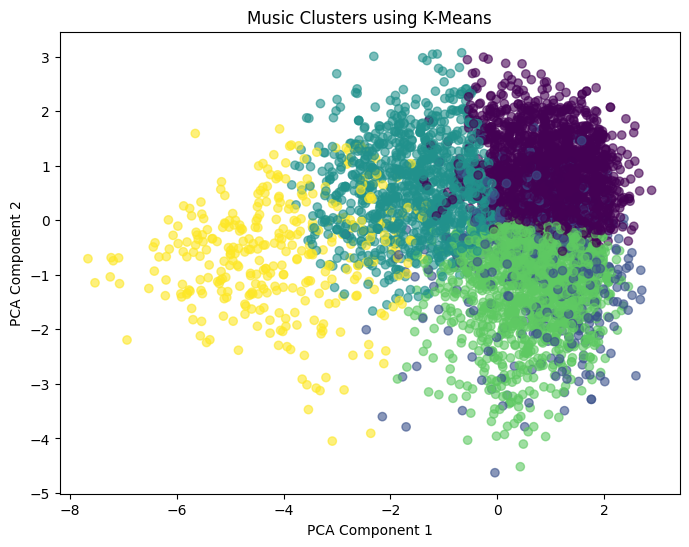

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    reduced_features[:,0],
    reduced_features[:,1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.title("Music Clusters using K-Means")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [13]:
df[df['cluster']==2][['track_name','artists']].head(10)

,track_name,artists
59311,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha
19261,I'll Be Home For Christmas - From The Kacey Mu...,Kacey Musgraves;Lana Del Rey
108051,Sur,Aníbal Troilo Y Su Orquesta Típica;Roberto Goy...
115,In Case You Didn’t Know,Boyce Avenue
87994,O Sopro do Fole,Maria Bethânia
98693,Everybody Loves Louis,Annaleigh Ashford
66367,Making Music,Blake Rules;Netherfriends
90796,Ruega por Mí (Prega Per Me),Estela Nuñez
7020,Holding,Yonder Mountain String Band
108522,Para dos,Orquesta Color Tango De Roberto Alvarez
